In [1]:
import pandas as pd 
from utils.general import (
    count_bar_plot,
    calculate_count_distribution,
    frequency_bar_plot,
    calculate_frequency_distribution,
    cross_tabulation_heatmap,
)
from utils.statistical import (
    calculate_cardinality,
    calculate_class_ratio,
    analyze_bias_crosstab,
    plot_gini_indexes,
    plot_entropies,
    chi_squared_test,
    calculate_cramers_v,
    plot_cramers_v_heatmap,
    calculate_class_ratio_between_most_least
)


%matplotlib inline

## Original Data

In [2]:
original_data = pd.read_csv(
    "../../local_data/01_bills/generated_data/concat_compiled_subjects_with_text.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    })


basic_random_under = pd.read_csv(
    "../../local_data/01_bills/generated_data/resampled_data/legislativeSubjects_basic_random_undersampling.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    }
)
basic_knn_under = pd.read_csv(
    "../../local_data/01_bills/generated_data/resampled_data/legislativeSubjects_basic_knn_undersampling.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    }
)
basic_nearmiss_under = pd.read_csv(
    "../../local_data/01_bills/generated_data/resampled_data/legislativeSubjects_basic_near_miss_undersampling.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    }
)


basic_random_over = pd.read_csv(
    "../../local_data/01_bills/generated_data/resampled_data/legislativeSubjects_basic_random_oversampling.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    }
)


random_under_over = pd.read_csv(
    "../../local_data/01_bills/generated_data/resampled_data/legislativeSubjects_rus_ros.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    }
)
random_over_under = pd.read_csv(
    "../../local_data/01_bills/generated_data/resampled_data/legislativeSubjects_ros_rus.csv.gz",
    compression="gzip",
    converters={
        "congress": str,
        "legislativeSubjects": pd.eval
    }
)

In [5]:
original_data.head(10)

,congress,billType,billNumber,legislativeSubjects,policyArea,billText
0,101,hconres,1,"[American economic assistance, American milita...",International Affairs,<pre>Â \nB37 6-6-89 [OC's]\nHCON 1 IH\n101st C...
1,101,hconres,10,"[Constitutional law, Meditation, Prayer in the...","Civil Rights and Liberties, Minority Issues",<pre>Â \nB37 Rosey 1/4/89 [Updated]\nHCON 10 I...
2,101,hconres,100,"[Genocide, Human rights, International relief,...",International Affairs,<pre>Â \nHCON 100 IH\n101st CONGRESS\n1st Sess...
3,101,hconres,101,"[AIDS (Disease), Drug abuse, Equipment and sup...",Health,<pre>Â \nHCON 101 IH\n101st CONGRESS\n1st Sess...
4,101,hconres,102,"[Hurricanes, Meteorology, Military aircraft, W...","Science, Technology, Communications",<pre>Â \nB37 4-25-89 [update]\nHCON 102 IH\n10...
5,101,hconres,103,"[Refugee policy, Refugees, Repatriation, Right...",International Affairs,<pre>Â \nHCON 103 IH\n101st CONGRESS\n1st Sess...
6,101,hconres,105,"[Aviation safety, Congressional investigations...",Congress,<pre>Â \nHCON 105 IH\n101st CONGRESS\n1st Sess...
7,101,hconres,107,"[Free trade, Mexico, Tariff, Trade agreements,...",Foreign Trade and International Finance,<pre>Â \nHCON 107 IH\n101st CONGRESS\n1st Sess...
8,101,hconres,108,"[Catholic Church, Israel, Recognition (Interna...",International Affairs,<pre>Â \nHCON 108 IH\n101st CONGRESS\n1st Sess...
9,101,hconres,109,"[Afghanistan, American economic assistance, Ch...",International Affairs,<pre>Â \nHCON 109 IH\n101st CONGRESS\n1st Sess...


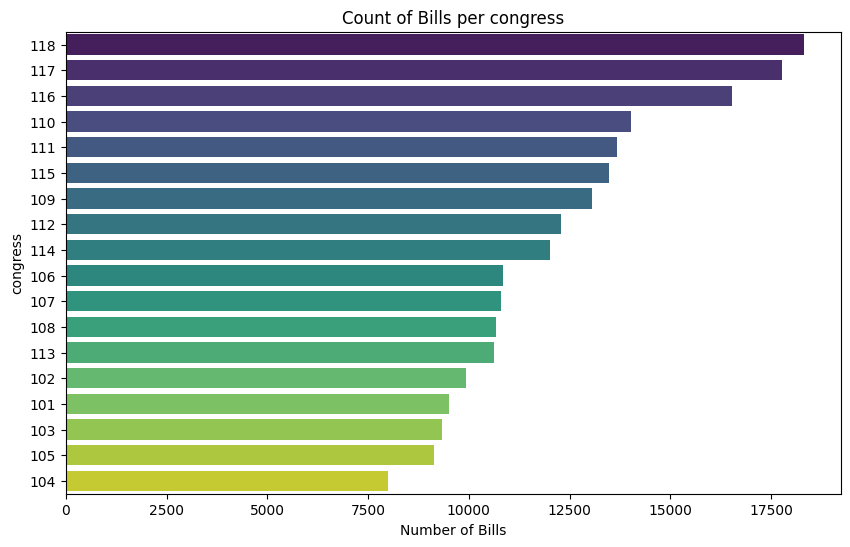

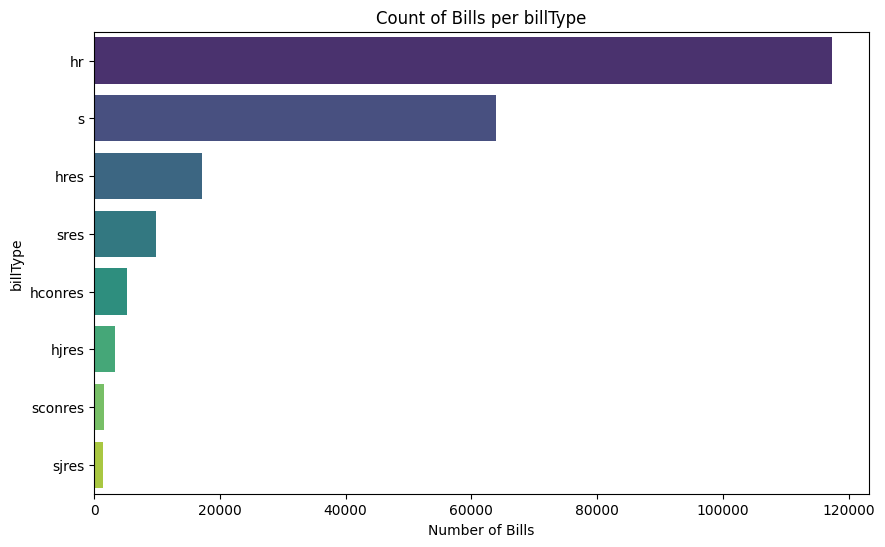

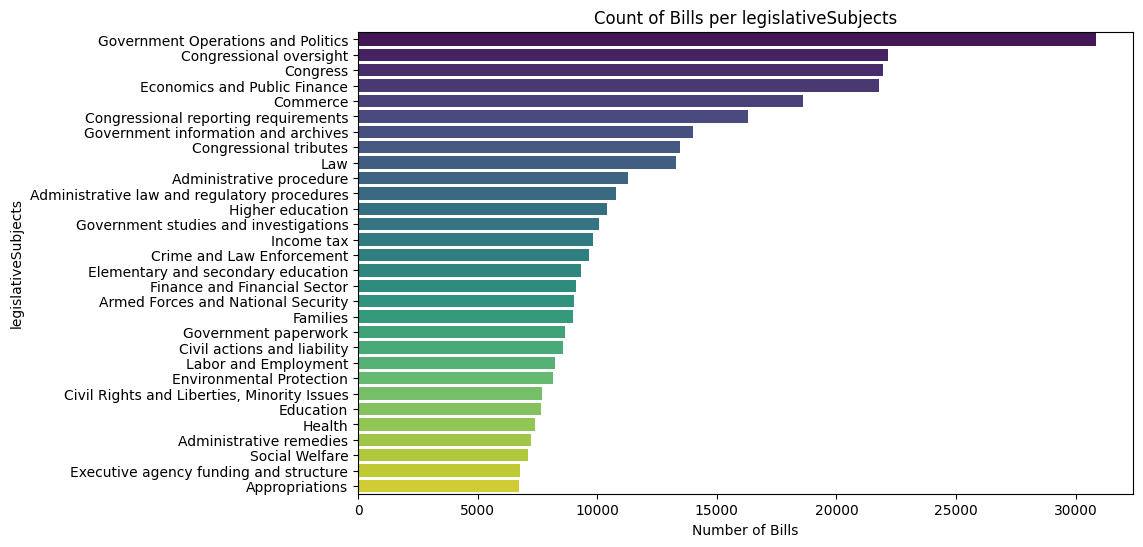

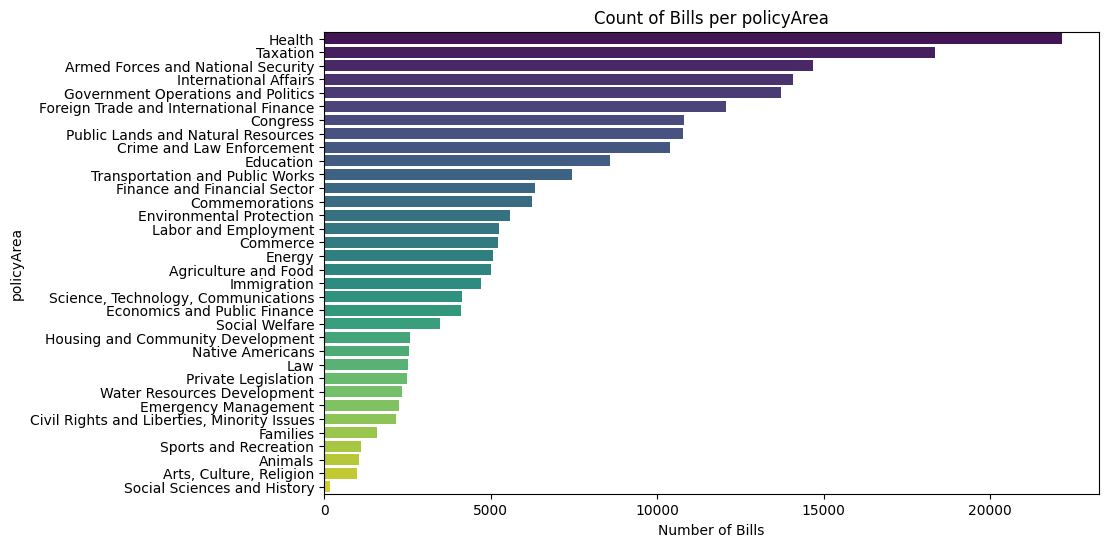

In [6]:
count_bar_plot(original_data, "congress")
count_bar_plot(original_data, "billType")
count_bar_plot(original_data, "legislativeSubjects", n=30)
count_bar_plot(original_data, "policyArea")

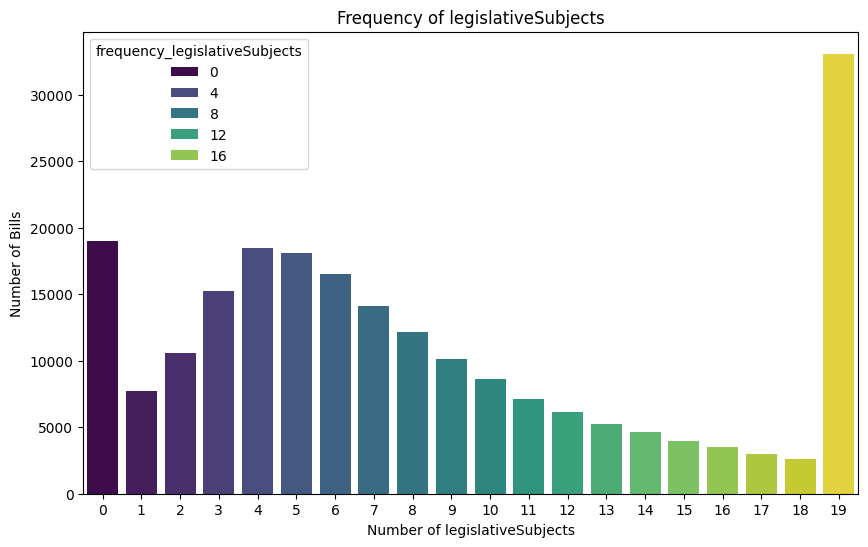

In [8]:
frequency_bar_plot(original_data, "legislativeSubjects")

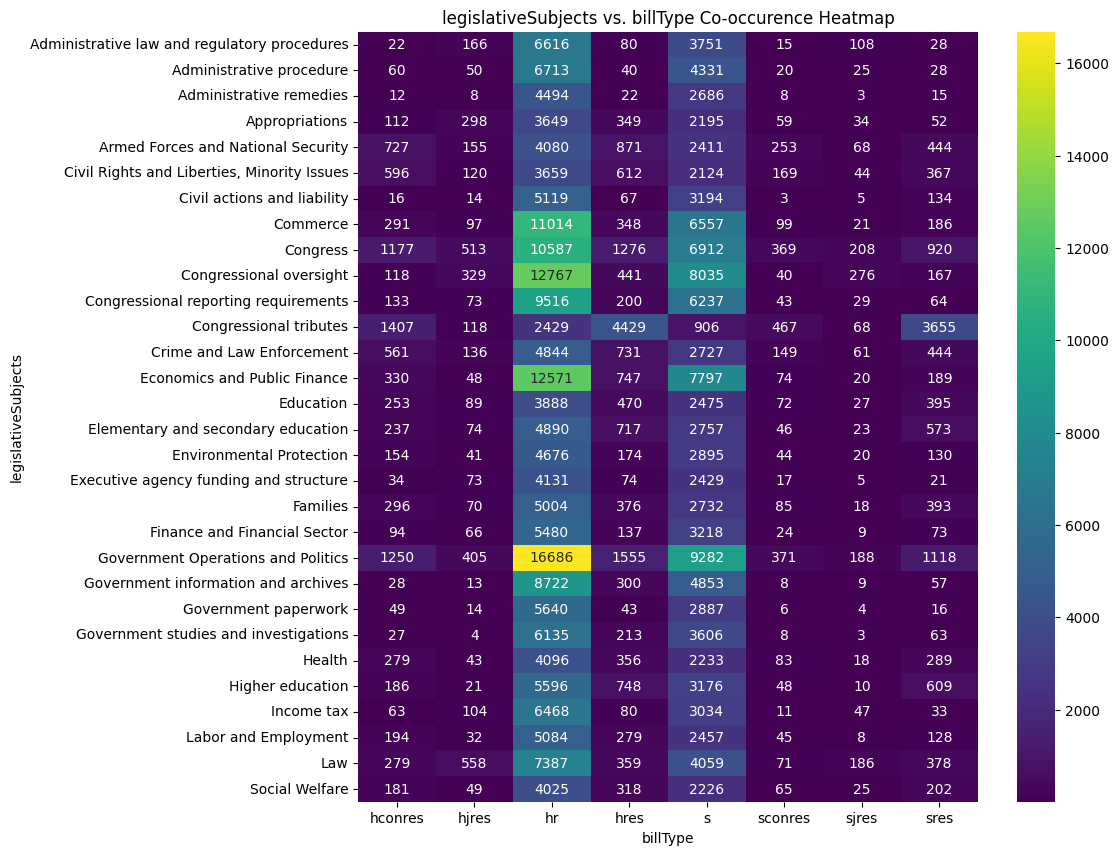

In [4]:
cross_tabulation_heatmap(original_data, ["legislativeSubjects", "billType"], n1=30)

In [11]:
calculate_cardinality(original_data, ["congress", "billType", "billNumber", "legislativeSubjects", "policyArea"])

congress                   18
billType                    8
billNumber              10042
legislativeSubjects      6210
policyArea                 34
billText               220012
dtype: int64

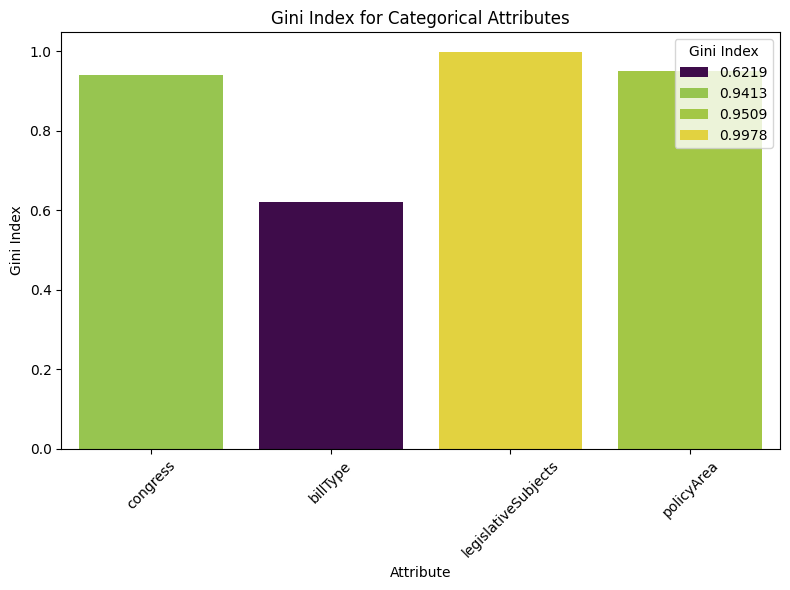

In [17]:
plot_gini_indexes(original_data, ["congress", "billType", "legislativeSubjects", "policyArea"])

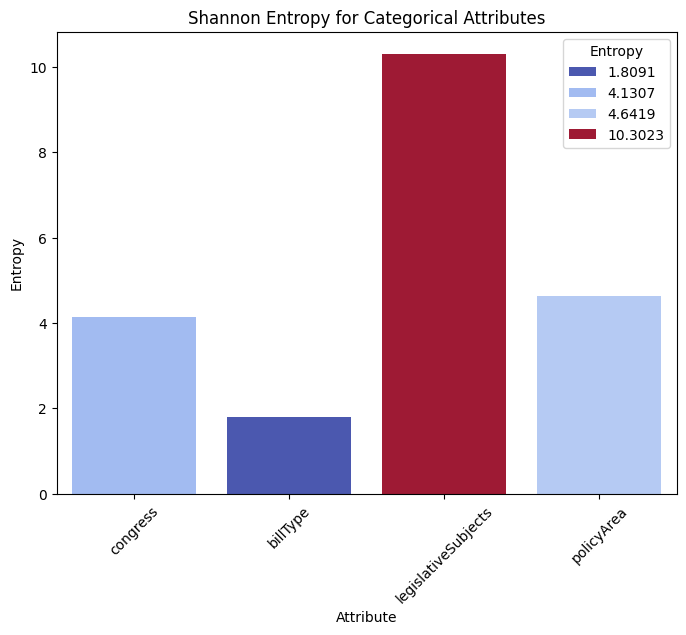

In [18]:
plot_entropies(original_data, ["congress", "billType", "legislativeSubjects", "policyArea"])

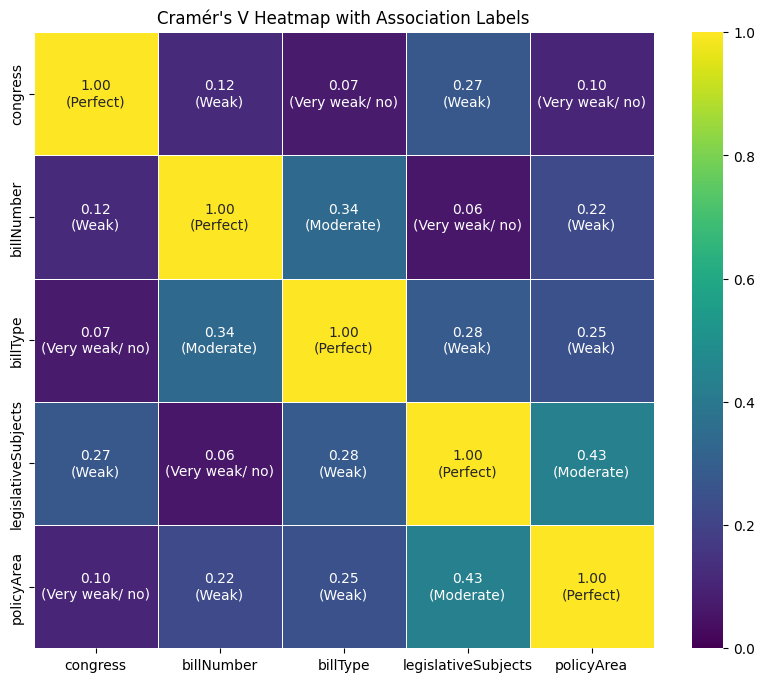

In [12]:
plot_cramers_v_heatmap(original_data, ["congress", "billNumber", "billType", "legislativeSubjects", "policyArea"])

In [ ]:
# calculate_class_ratio(original_data, "legislativeSubjects", n=5)

Most dominant values in legislativeSubjects:
legislativeSubjects
Government Operations and Politics    0.016764
Congressional oversight               0.012047
Congress                              0.011932
Economics and Public Finance          0.011831
Commerce                              0.010113
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
House Select Committee on Energy Independence and Global Warming    5.433200e-07
Monaco                                                              5.433200e-07
Andorra                                                             5.433200e-07
Airline law and legislation                                         5.433200e-07
Renegotiation                                                       5.433200e-07
Name: proportion, dtype: float64


legislativeSubjects
Government Operations and Politics                                  1.676414e-02
Congressional oversight                                             1.204703e-02
Congress                                                            1.193239e-02
Economics and Public Finance                                        1.183134e-02
Commerce                                                            1.011281e-02
                                                                        ...     
House Select Committee on Energy Independence and Global Warming    5.433200e-07
Monaco                                                              5.433200e-07
Andorra                                                             5.433200e-07
Airline law and legislation                                         5.433200e-07
Renegotiation                                                       5.433200e-07
Name: proportion, Length: 6210, dtype: float64

In [ ]:
# calculate_class_ratio(original_data, "policyArea", n=5)

Most dominant values in policyArea:
policyArea
Health                                0.100694
Taxation                              0.083286
Armed Forces and National Security    0.066737
International Affairs                 0.063955
Government Operations and Politics    0.062328
Name: proportion, dtype: float64

Least dominant values in policyArea:
policyArea
Families                       0.007195
Sports and Recreation          0.005109
Animals                        0.004741
Arts, Culture, Religion        0.004563
Social Sciences and History    0.000859
Name: proportion, dtype: float64


policyArea
Health                                         0.100694
Taxation                                       0.083286
Armed Forces and National Security             0.066737
International Affairs                          0.063955
Government Operations and Politics             0.062328
Foreign Trade and International Finance        0.054874
Congress                                       0.049102
Public Lands and Natural Resources             0.048906
Crime and Law Enforcement                      0.047220
Education                                      0.038989
Transportation and Public Works                0.033771
Finance and Financial Sector                   0.028748
Commemorations                                 0.028357
Environmental Protection                       0.025403
Labor and Employment                           0.023912
Commerce                                       0.023712
Energy                                         0.023117
Agriculture and Food                 

In [19]:
calculate_class_ratio_between_most_least(original_data, "legislativeSubjects")

Most dominant values in legislativeSubjects:
legislativeSubjects
Government Operations and Politics    0.016764
Congressional oversight               0.012047
Congress                              0.011932
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
Andorra                        5.433200e-07
Airline law and legislation    5.433200e-07
Renegotiation                  5.433200e-07
Name: proportion, dtype: float64
Overall Imbalance Ratio: 3e-05


### Random Undersampling

In [20]:
calculate_class_ratio_between_most_least(basic_random_under, "legislativeSubjects")

Most dominant values in legislativeSubjects:
legislativeSubjects
Blood and blood diseases    0.000161
Meat substitutes            0.000161
Vegetarianism               0.000161
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
Mines (Ordnance)    0.000161
Tropical forests    0.000161
Fuel research       0.000161
Name: proportion, dtype: float64
Overall Imbalance Ratio: 1.0


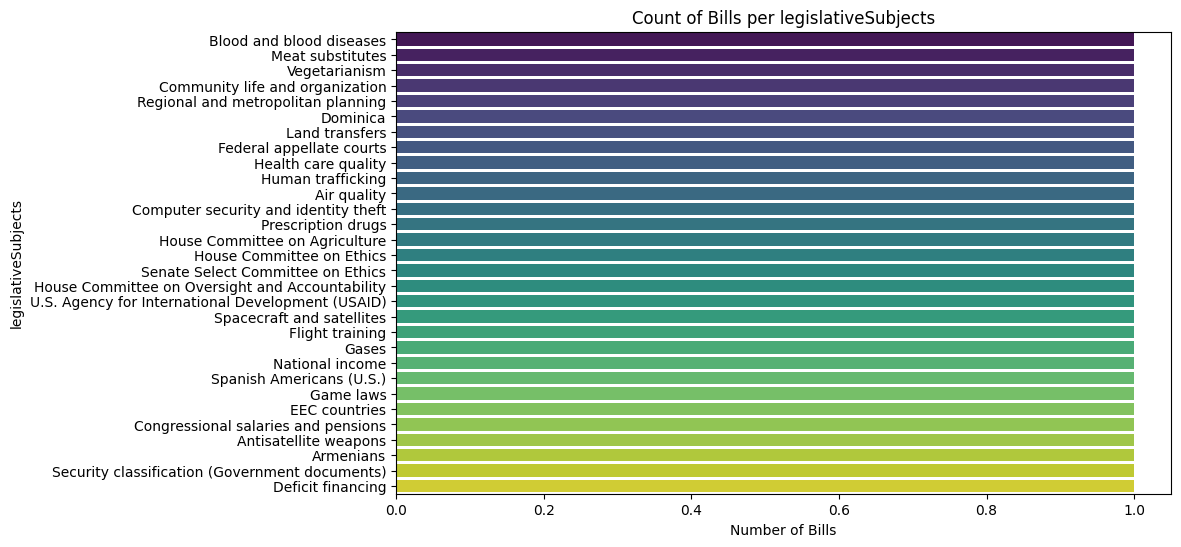

Number of examples: 5965


In [22]:
count_bar_plot(basic_random_under, "legislativeSubjects", n=30)
print(f"Number of examples: {len(basic_random_under)}")

### k-Nearest-Neighbors Undersampling

In [24]:
calculate_class_ratio_between_most_least(basic_knn_under, "legislativeSubjects")

Most dominant values in legislativeSubjects:
legislativeSubjects
Government Operations and Politics    0.016987
Congressional oversight               0.012188
Congress                              0.012121
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
Food substitutes    5.521787e-07
Status offenders    5.521787e-07
Monaco              5.521787e-07
Name: proportion, dtype: float64
Overall Imbalance Ratio: 3e-05


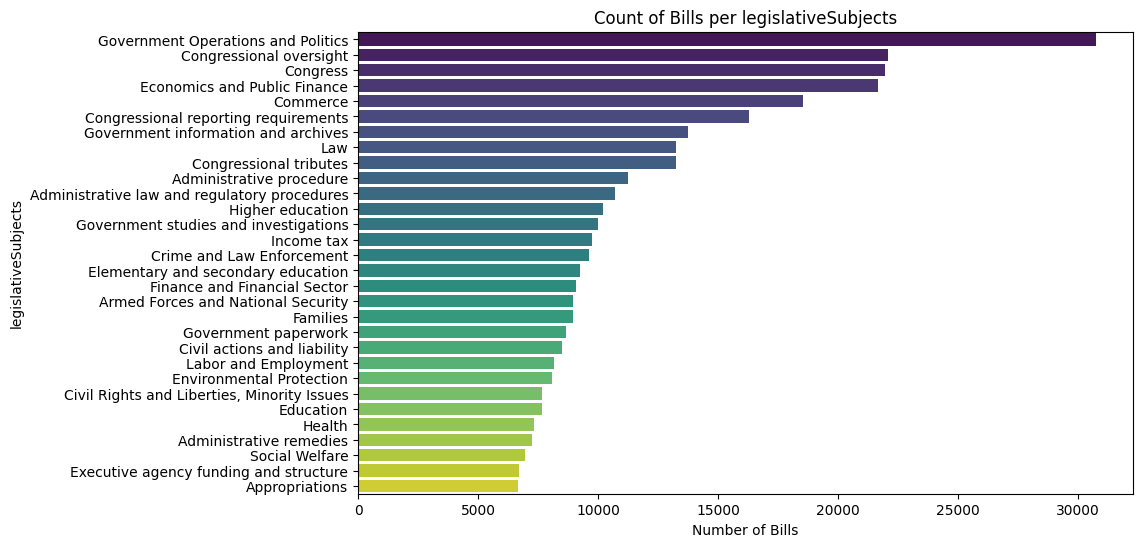

Number of examples: 197799


In [25]:
count_bar_plot(basic_knn_under, "legislativeSubjects", n=30)
print(f"Number of examples: {len(basic_knn_under)}")

### NearMiss Undersampling

In [26]:
calculate_class_ratio_between_most_least(basic_nearmiss_under, "legislativeSubjects")

Most dominant values in legislativeSubjects:
legislativeSubjects
Government Operations and Politics      0.019870
Congress                                0.013175
Congressional reporting requirements    0.011502
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
Mars probes                  0.000021
Local service airlines       0.000021
Put and call transactions    0.000021
Name: proportion, dtype: float64
Overall Imbalance Ratio: 0.00108


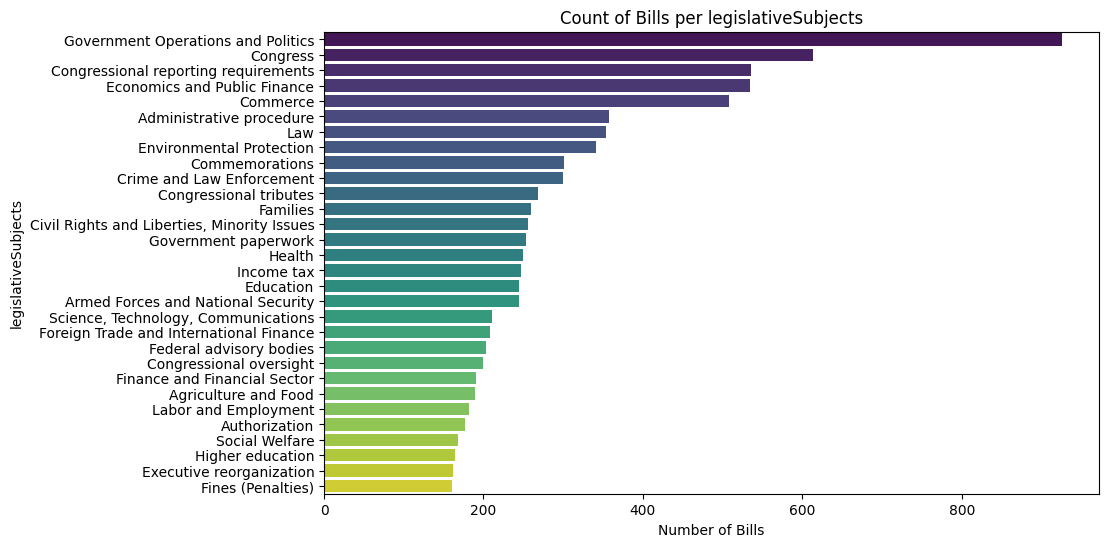

Number of examples: 4160


In [27]:
count_bar_plot(basic_nearmiss_under, "legislativeSubjects", n=30)
print(f"Number of examples: {len(basic_nearmiss_under)}")

### Random Oversampling

In [28]:
calculate_class_ratio_between_most_least(basic_random_over, "legislativeSubjects")

Most dominant values in legislativeSubjects:
legislativeSubjects
Government Operations and Politics    0.016571
Congressional oversight               0.011908
Congress                              0.011795
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
Quality circles                    0.000003
Materials management               0.000003
Delaware River Basin Commission    0.000003
Name: proportion, dtype: float64
Overall Imbalance Ratio: 0.00016


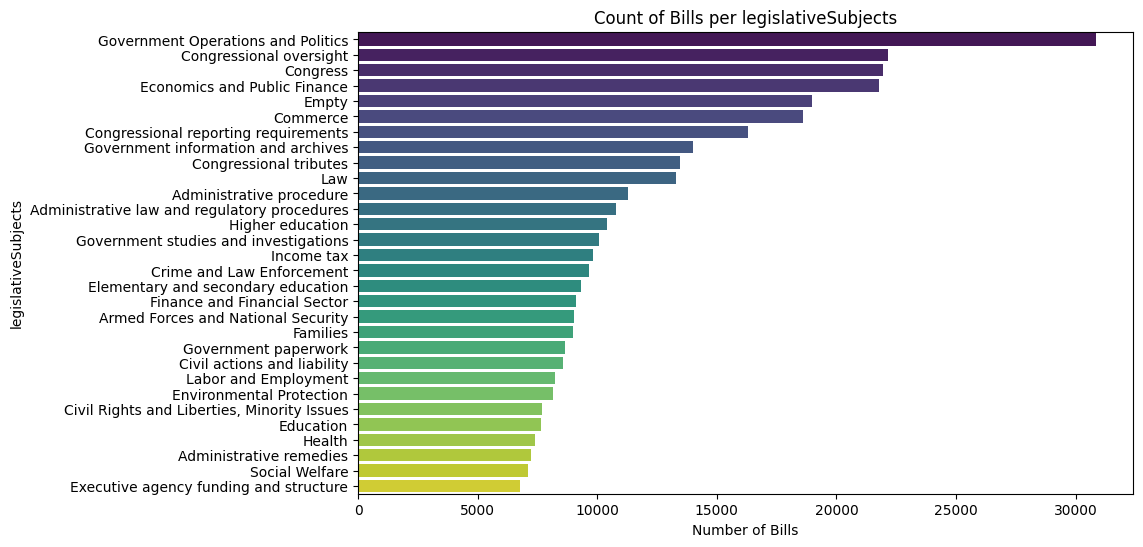

Number of examples: 220013


In [29]:
count_bar_plot(basic_random_over, "legislativeSubjects", n=30)
print(f"Number of examples: {len(basic_random_over)}")

### Hybrid: Random Undersampling following by Random Oversampling

In [30]:
calculate_class_ratio_between_most_least(random_under_over, "legislativeSubjects")

Most dominant values in legislativeSubjects:
legislativeSubjects
Foreign property        0.000244
Educational guidance    0.000244
Debt collection         0.000244
Name: proportion, dtype: float64

Least dominant values in legislativeSubjects:
legislativeSubjects
House Select Committee on Energy Independence and Global Warming    0.000024
Light                                                               0.000024
Food as a weapon                                                    0.000024
Name: proportion, dtype: float64
Overall Imbalance Ratio: 0.1


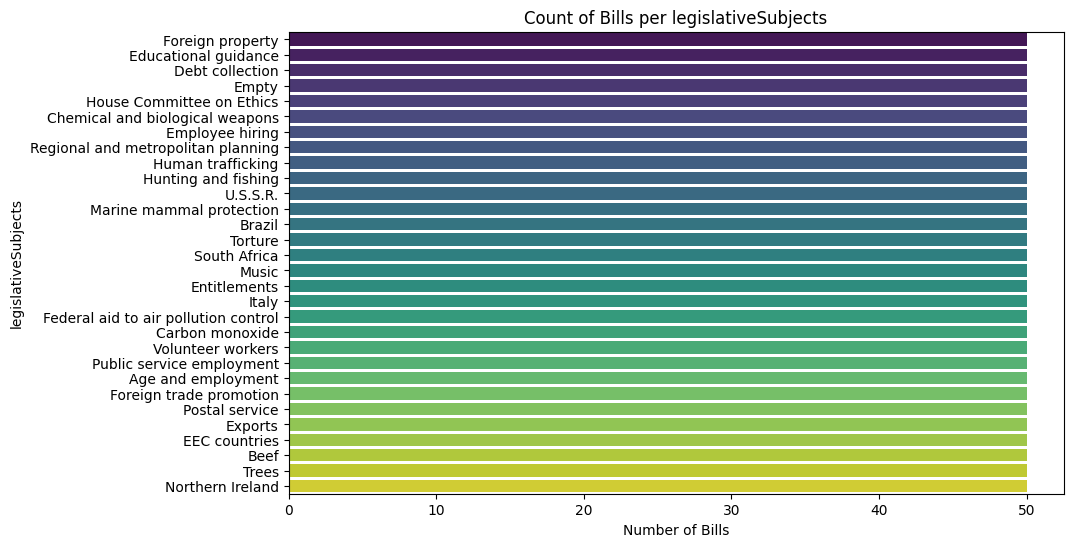

Number of examples: 101051


In [31]:
count_bar_plot(random_under_over, "legislativeSubjects", n=30)
print(f"Number of examples: {len(random_under_over)}")